In [1]:
import pyteomics
import lxml
from pyteomics import mzml, mass
import numpy as np
import matplotlib.pyplot as plt
import os
import pandas as pd
import re
from scipy.stats import pearsonr, spearmanr, linregress
import matplotlib
import seaborn as sns

In [2]:
fileslist = []
dir = 'D:\\yuming\\2023\\20230321\\QL_realsample\\mzml'
for file in os.listdir(dir):
    if file.endswith(".mzML"):
        fileslist.append(os.path.join(dir, file))
print(fileslist)

['D:\\yuming\\2023\\20230321\\QL_realsample\\mzml\\QL6_2.mzML', 'D:\\yuming\\2023\\20230321\\QL_realsample\\mzml\\QL6_3.mzML', 'D:\\yuming\\2023\\20230321\\QL_realsample\\mzml\\QL1_2.mzML', 'D:\\yuming\\2023\\20230321\\QL_realsample\\mzml\\QL1.mzML', 'D:\\yuming\\2023\\20230321\\QL_realsample\\mzml\\QL1_3.mzML', 'D:\\yuming\\2023\\20230321\\QL_realsample\\mzml\\QL2.mzML', 'D:\\yuming\\2023\\20230321\\QL_realsample\\mzml\\QL2_2.mzML', 'D:\\yuming\\2023\\20230321\\QL_realsample\\mzml\\QL2_3.mzML', 'D:\\yuming\\2023\\20230321\\QL_realsample\\mzml\\QL3.mzML', 'D:\\yuming\\2023\\20230321\\QL_realsample\\mzml\\QL3_2.mzML', 'D:\\yuming\\2023\\20230321\\QL_realsample\\mzml\\QL3_3.mzML', 'D:\\yuming\\2023\\20230321\\QL_realsample\\mzml\\QL4.mzML', 'D:\\yuming\\2023\\20230321\\QL_realsample\\mzml\\QL4_2.mzML', 'D:\\yuming\\2023\\20230321\\QL_realsample\\mzml\\QL4_3.mzML', 'D:\\yuming\\2023\\20230321\\QL_realsample\\mzml\\QL5.mzML', 'D:\\yuming\\2023\\20230321\\QL_realsample\\mzml\\QL5_2.mzML', '

In [3]:
# find the mzml files for each dilution 

mzmls_0= [x for x in fileslist if 'QL0' in x]
mzmls_1= [x for x in fileslist if 'QL1' in x]
mzmls_2= [x for x in fileslist if 'QL2' in x]
mzmls_3= [x for x in fileslist if 'QL3' in x]
mzmls_4= [x for x in fileslist if 'QL4' in x]
mzmls_5= [x for x in fileslist if 'QL5' in x]
mzmls_6= [x for x in fileslist if 'QL6' in x]


In [113]:
mzmls_1

['D:\\yuming\\2023\\20230321\\QL_realsample\\mzml\\QL1_2.mzML',
 'D:\\yuming\\2023\\20230321\\QL_realsample\\mzml\\QL1.mzML',
 'D:\\yuming\\2023\\20230321\\QL_realsample\\mzml\\QL1_3.mzML']

In [7]:
def Average(lst):
    return sum(lst) / len(lst)

In [33]:
def getlipid_inten(mzmls=mzmls_1,num=0,name='QL1'):
    tmp_00= pyteomics.mzml.read(mzmls[num], use_index=True)
    sum_711=[]
    sum_738=[]
    sum_753=[]
    sum_529=[]
    sum_781=[]
    # change the numbers below if your lipid scans are different
    for i in range(50,280):
        if (float(tmp_00.get_by_index(i)['base peak m/z'])>710) & (float(tmp_00.get_by_index(i)['base peak m/z'])<713):
            sum_711.append(int(tmp_00.get_by_index(i)['base peak intensity']))
        if (float(tmp_00.get_by_index(i)['base peak m/z'])>737) & (float(tmp_00.get_by_index(i)['base peak m/z'])<740):
            sum_738.append(int(tmp_00.get_by_index(i)['base peak intensity']))
        if (float(tmp_00.get_by_index(i)['base peak m/z'])>753) & (float(tmp_00.get_by_index(i)['base peak m/z'])<755):
            sum_753.append(int(tmp_00.get_by_index(i)['base peak intensity']))
        if (float(tmp_00.get_by_index(i)['base peak m/z'])>527) & (float(tmp_00.get_by_index(i)['base peak m/z'])<530):
            sum_529.append(int(tmp_00.get_by_index(i)['base peak intensity'])) 
        if (float(tmp_00.get_by_index(i)['base peak m/z'])>780) & (float(tmp_00.get_by_index(i)['base peak m/z'])<783):
            sum_781.append(int(tmp_00.get_by_index(i)['base peak intensity']))  
            
    lipid_intensity={'lipid_711'+'%s' % str(name):sum_711[:20],'lipid_738'+'%s' % str(name):sum_738[:20],
                     'lipid_753'+'%s' % str(name):sum_753[:20],'lipid_781'+'%s' % str(name):sum_781[:20],
                     'lipid_529'+'%s' % str(name):sum_529[:20]}
    
    df=pd.DataFrame(lipid_intensity)
    #df.set_index('lipid_name',inplace=True)
    return(df)

In [56]:
getlipid_inten(mzmls=mzmls_1,num=0,name='QL1')

,lipid_711QL1,lipid_738QL1,lipid_753QL1,lipid_781QL1,lipid_529QL1
0,41081,75237,372356,2285483,352383
1,40650,70074,446540,2115877,340094
2,55467,54458,412304,2236001,371313
3,44932,56491,341508,2058490,384806
4,45510,67693,366968,2430934,352751
5,43082,60153,348062,2584135,364038
6,53834,71219,402965,2070982,355048
7,49625,57881,333482,2139521,361307
8,48793,66783,382147,1869424,344287
9,44784,64822,391799,2257365,376778


In [40]:
dfa_QL1=pd.concat([pd.DataFrame(getlipid_inten(mzmls=mzmls_1,num=0,name='QL1_1').iloc[:,0]),
                  pd.DataFrame(getlipid_inten(mzmls=mzmls_1,num=1,name='QL1_2').iloc[:,0]),
                  pd.DataFrame(getlipid_inten(mzmls=mzmls_1,num=2,name='QL1_3').iloc[:,0])], axis=1)

dfa_QL2=pd.concat([pd.DataFrame(getlipid_inten(mzmls=mzmls_2,num=0,name='QL2_1').iloc[:,0]),
                  pd.DataFrame(getlipid_inten(mzmls=mzmls_2,num=1,name='QL2_2').iloc[:,0]),
                  pd.DataFrame(getlipid_inten(mzmls=mzmls_2,num=2,name='QL2_3').iloc[:,0])], axis=1)

dfa_QL3=pd.concat([pd.DataFrame(getlipid_inten(mzmls=mzmls_3,num=0,name='QL3_1').iloc[:,0]),
                  pd.DataFrame(getlipid_inten(mzmls=mzmls_3,num=1,name='QL3_2').iloc[:,0]),
                  pd.DataFrame(getlipid_inten(mzmls=mzmls_3,num=2,name='QL3_3').iloc[:,0])], axis=1)

dfa_QL4=pd.concat([pd.DataFrame(getlipid_inten(mzmls=mzmls_4,num=0,name='QL4_1').iloc[:,0]),
                  pd.DataFrame(getlipid_inten(mzmls=mzmls_4,num=1,name='QL4_2').iloc[:,0]),
                  pd.DataFrame(getlipid_inten(mzmls=mzmls_4,num=2,name='QL4_3').iloc[:,0])], axis=1)

dfa_QL5=pd.concat([pd.DataFrame(getlipid_inten(mzmls=mzmls_5,num=0,name='QL5_1').iloc[:,0]),
                  pd.DataFrame(getlipid_inten(mzmls=mzmls_5,num=1,name='QL5_2').iloc[:,0]),
                  pd.DataFrame(getlipid_inten(mzmls=mzmls_5,num=2,name='QL5_3').iloc[:,0])], axis=1)

dfa_QL6=pd.concat([pd.DataFrame(getlipid_inten(mzmls=mzmls_6,num=0,name='QL6_1').iloc[:,0]),
                  pd.DataFrame(getlipid_inten(mzmls=mzmls_6,num=1,name='QL6_2').iloc[:,0]),
                  pd.DataFrame(getlipid_inten(mzmls=mzmls_6,num=2,name='QL6_3').iloc[:,0])], axis=1)



In [42]:
dfaa_QL1=pd.concat([getlipid_inten(mzmls=mzmls_1,num=0,name='QL1_1'),
                 getlipid_inten(mzmls=mzmls_1,num=1,name='QL1_2'),
                  getlipid_inten(mzmls=mzmls_1,num=2,name='QL1_3')], axis=1)

dfaa_QL2=pd.concat([getlipid_inten(mzmls=mzmls_2,num=0,name='QL2_1'),
                  getlipid_inten(mzmls=mzmls_2,num=1,name='QL2_2'),
                  getlipid_inten(mzmls=mzmls_2,num=2,name='QL2_3')], axis=1)

dfaa_QL3=pd.concat([getlipid_inten(mzmls=mzmls_3,num=0,name='QL3_1'),
                  getlipid_inten(mzmls=mzmls_3,num=1,name='QL3_2'),
                  getlipid_inten(mzmls=mzmls_3,num=2,name='QL3_3')], axis=1)

dfaa_QL4=pd.concat([getlipid_inten(mzmls=mzmls_4,num=0,name='QL4_1'),
                  getlipid_inten(mzmls=mzmls_4,num=1,name='QL4_2'),
                  getlipid_inten(mzmls=mzmls_4,num=2,name='QL4_3')], axis=1)

dfaa_QL5=pd.concat([getlipid_inten(mzmls=mzmls_5,num=0,name='QL5_1'),
                  getlipid_inten(mzmls=mzmls_5,num=1,name='QL5_2'),
                  getlipid_inten(mzmls=mzmls_5,num=2,name='QL5_3')], axis=1)

dfaa_QL6=pd.concat([getlipid_inten(mzmls=mzmls_6,num=0,name='QL6_1'),
                  getlipid_inten(mzmls=mzmls_6,num=1,name='QL6_2'),
                  getlipid_inten(mzmls=mzmls_6,num=2,name='QL6_3')], axis=1)

In [43]:
dfaa_QL1

,lipid_711QL1_1,lipid_738QL1_1,lipid_753QL1_1,lipid_781QL1_1,lipid_529QL1_1,lipid_711QL1_2,lipid_738QL1_2,lipid_753QL1_2,lipid_781QL1_2,lipid_529QL1_2,lipid_711QL1_3,lipid_738QL1_3,lipid_753QL1_3,lipid_781QL1_3,lipid_529QL1_3
0,41081,75237,372356,2285483,352383,36350,64245,167642,926359,176333,40232,49560,379993,1581841,299375
1,40650,70074,446540,2115877,340094,65152,76077,124600,1939669,169542,47069,58385,293138,1560806,276671
2,55467,54458,412304,2236001,371313,48254,64681,186450,2000779,177076,51265,48563,268935,1961904,295684
3,44932,56491,341508,2058490,384806,34355,57783,121732,1330567,165719,44423,54074,273874,1567332,281833
4,45510,67693,366968,2430934,352751,40498,66233,121467,1046843,163304,49836,50789,260759,1411953,254286
5,43082,60153,348062,2584135,364038,46866,55480,146615,1360976,162636,54166,53663,251161,1539894,307151
6,53834,71219,402965,2070982,355048,52673,51568,138057,962697,190993,39268,54653,238099,1361941,245737
7,49625,57881,333482,2139521,361307,50240,63128,112181,1079332,170269,46225,55895,300852,1562795,294015
8,48793,66783,382147,1869424,344287,46653,60293,136749,1375384,179115,52969,56374,287577,1543746,295211
9,44784,64822,391799,2257365,376778,51487,65217,124042,1156228,177244,42711,60328,217248,2238187,272223


In [44]:
dfaa_all=pd.concat([dfaa_QL1,dfaa_QL2,dfaa_QL3,dfaa_QL4,dfaa_QL5,dfaa_QL6],axis=1)

In [45]:
dfaa_all

,lipid_711QL1_1,lipid_738QL1_1,lipid_753QL1_1,lipid_781QL1_1,lipid_529QL1_1,lipid_711QL1_2,lipid_738QL1_2,lipid_753QL1_2,lipid_781QL1_2,lipid_529QL1_2,...,lipid_711QL6_2,lipid_738QL6_2,lipid_753QL6_2,lipid_781QL6_2,lipid_529QL6_2,lipid_711QL6_3,lipid_738QL6_3,lipid_753QL6_3,lipid_781QL6_3,lipid_529QL6_3
0,41081,75237,372356,2285483,352383,36350,64245,167642,926359,176333,...,2679049,34281412,398745888,6060343,339889568,2168439,34243584,265454320,4489867,281488160
1,40650,70074,446540,2115877,340094,65152,76077,124600,1939669,169542,...,2891229,48598648,568872768,6001327,422664960,2191829,30328088,501510400,4370775,286292128
2,55467,54458,412304,2236001,371313,48254,64681,186450,2000779,177076,...,2999136,39425208,556510464,6381230,362421664,2330565,46737220,402358496,4864009,283343680
3,44932,56491,341508,2058490,384806,34355,57783,121732,1330567,165719,...,2824355,50723912,557520128,6317283,463928064,1701574,35249920,607150592,4667903,291068416
4,45510,67693,366968,2430934,352751,40498,66233,121467,1046843,163304,...,2796045,50225696,401172320,5323335,376355712,2115927,31236156,153412320,4433003,269711328
5,43082,60153,348062,2584135,364038,46866,55480,146615,1360976,162636,...,2889351,48337680,508669984,6181931,391912864,2890595,37232636,390717920,4998089,292335456
6,53834,71219,402965,2070982,355048,52673,51568,138057,962697,190993,...,3078614,51791328,388418912,6276476,375246208,2412748,56924020,194670608,5454809,306108736
7,49625,57881,333482,2139521,361307,50240,63128,112181,1079332,170269,...,3335288,53168212,439699744,6070259,399077344,2014897,30308556,520273696,6681698,289416736
8,48793,66783,382147,1869424,344287,46653,60293,136749,1375384,179115,...,2865935,54156660,644653952,6546694,439256096,2562265,25853198,351176064,3996621,320225056
9,44784,64822,391799,2257365,376778,51487,65217,124042,1156228,177244,...,2869652,56079248,463083040,7112211,397934688,2159433,39026776,374185760,3940062,293214336


In [66]:
def getdfwo(name="lipid_753"):
    kld=np.log2(dfaa_all.filter(like=name))
    j1=kld.iloc[:,:3].values.tolist()
    j2=kld.iloc[:,3:6].values.tolist()
    j3=kld.iloc[:,6:9].values.tolist()
    j4=kld.iloc[:,9:12].values.tolist()
    j5=kld.iloc[:,12:15].values.tolist()
    j6=kld.iloc[:,15:18].values.tolist()
    new_list1 = [item for sublist in j1 for item in sublist]
    new_list2 = [item for sublist in j2 for item in sublist]
    new_list3 = [item for sublist in j3 for item in sublist]
    new_list4 = [item for sublist in j4 for item in sublist]
    new_list5 = [item for sublist in j5 for item in sublist]
    new_list6 = [item for sublist in j6 for item in sublist]
    lipid={'QL1':new_list1,'QL2':new_list2,'QL3':new_list3,'QL4':new_list4,'QL5':new_list5,'QL6':new_list6}
    df=pd.DataFrame(lipid)
    return(df)




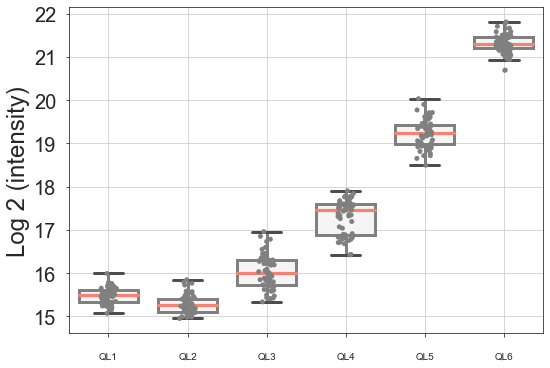

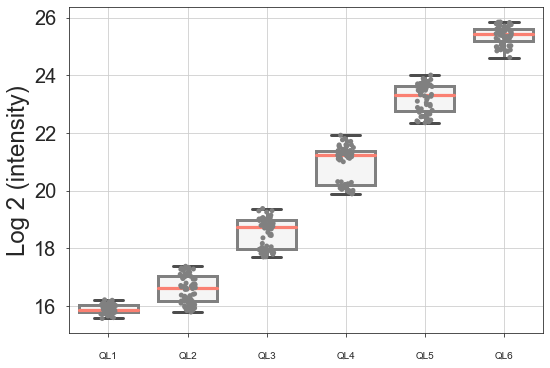

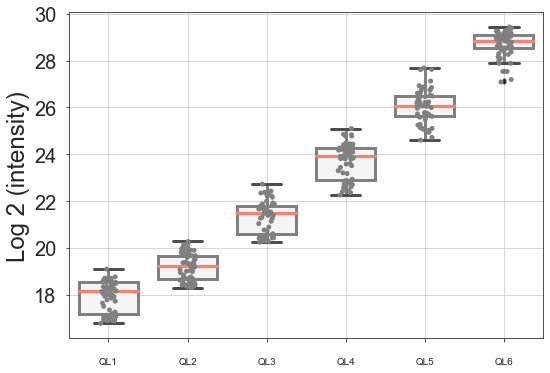

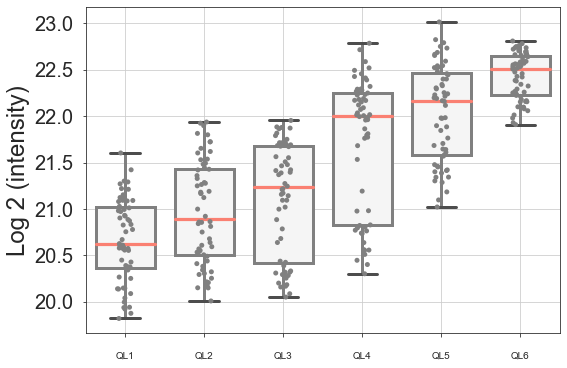

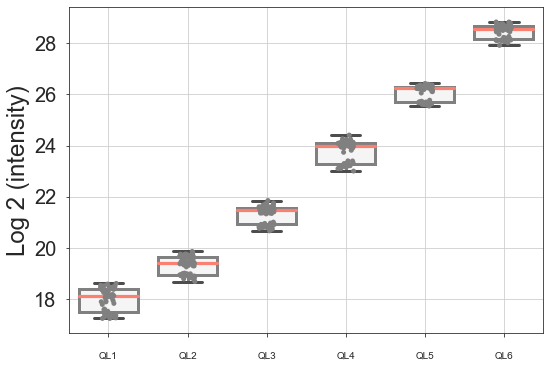

In [86]:
# Plot all common peptides after take log10 
for nameindex in ['lipid_711','lipid_738','lipid_753','lipid_781','lipid_529']:
    matplotlib.rcParams['font.family'] = "Arial"
    plt.figure(figsize=(8.5, 6))
    sns.boxplot(data=getdfwo(name=nameindex), orient='v',color="grey", boxprops=dict(facecolor="whitesmoke",edgecolor='grey',linewidth=3), 
                whiskerprops=dict(color="grey",linewidth=3), medianprops=dict(color="salmon",linewidth=3.2), width=0.75,fliersize=6,
               flierprops=dict(markerfacecolor="black", marker="."),linewidth=3)
    sns.stripplot(data=getdfwo(name=nameindex), color="grey")
    #plt.rc('xtick', labelsize=12, fontfamily='Arial')
    #plt.rc('ytick', labelsize=12, fontfamily='Arial')
    plt.ylabel('Log 2 (intensity)',fontsize=24)
    plt.tick_params(axis='x', which='major', pad=15)
    plt.tick_params(axis='y', which='major', pad=9)
    plt.xticks(fontsize=10)
    plt.yticks(fontsize=20)
    #plt.ylim(3.5,7.5)
    plt.grid()
    plt.savefig(r'D:\\project7_SMAD\\figure2\\quantification\\%s.svg' % nameindex,dpi=800,bbox_inches='tight')
    plt.show()

In [8]:
def getlipid_inten_aver(mzmls=mzmls_1,num=0,name='QL1'):
    tmp_00= pyteomics.mzml.read(mzmls[num], use_index=True)
    sum_711=[]
    sum_738=[]
    sum_753=[]
    sum_529=[]
    sum_781=[]
    # change the numbers below if your lipid scans are different
    for i in range(50,280):
        if (float(tmp_00.get_by_index(i)['base peak m/z'])>710) & (float(tmp_00.get_by_index(i)['base peak m/z'])<713):
            sum_711.append(int(tmp_00.get_by_index(i)['base peak intensity']))
        if (float(tmp_00.get_by_index(i)['base peak m/z'])>737) & (float(tmp_00.get_by_index(i)['base peak m/z'])<740):
            sum_738.append(int(tmp_00.get_by_index(i)['base peak intensity']))
        if (float(tmp_00.get_by_index(i)['base peak m/z'])>753) & (float(tmp_00.get_by_index(i)['base peak m/z'])<755):
            sum_753.append(int(tmp_00.get_by_index(i)['base peak intensity']))
        if (float(tmp_00.get_by_index(i)['base peak m/z'])>527) & (float(tmp_00.get_by_index(i)['base peak m/z'])<530):
            sum_529.append(int(tmp_00.get_by_index(i)['base peak intensity'])) 
        if (float(tmp_00.get_by_index(i)['base peak m/z'])>780) & (float(tmp_00.get_by_index(i)['base peak m/z'])<783):
            sum_781.append(int(tmp_00.get_by_index(i)['base peak intensity']))  
            
    lipid_name=['lipid_711','lipid_738','lipid_753','lipid_781','lipid_529']
    lipid_intensity=[Average(sum_711),Average(sum_738),Average(sum_753),Average(sum_781),Average(sum_529)]
    
    dict_lipid = {'lipid_name':lipid_name,'%s' % str(name):lipid_intensity}
    df=pd.DataFrame(dict_lipid)
    df.set_index('lipid_name',inplace=True)
    return(df)

In [9]:
getlipid_inten_aver(mzmls=mzmls_1,num=0,name='QL1')

,QL1
lipid_name,
lipid_711,4.665181e+04
lipid_738,6.578038e+04
lipid_753,3.897698e+05
lipid_781,2.291187e+06
lipid_529,3.534577e+05


In [16]:
df_QL1=pd.concat([getlipid_inten_aver(mzmls=mzmls_1,num=0,name='QL1_1'),
                  getlipid_inten_aver(mzmls=mzmls_1,num=1,name='QL1_2'),
                  getlipid_inten_aver(mzmls=mzmls_1,num=2,name='QL1_3')], axis=1)

In [37]:
df_QL1

,QL1_1,QL1_2,QL1_3
lipid_name,,,
lipid_711,4.665181e+04,4.635725e+04,4.491914e+04
lipid_738,6.578038e+04,6.080400e+04,5.646590e+04
lipid_753,3.897698e+05,1.409048e+05,2.957927e+05
lipid_781,2.291187e+06,1.246510e+06,1.692707e+06
lipid_529,3.534577e+05,1.808365e+05,2.896140e+05


In [17]:
df_QL2=pd.concat([getlipid_inten_aver(mzmls=mzmls_2,num=0,name='QL2_1'),
                  getlipid_inten_aver(mzmls=mzmls_2,num=1,name='QL2_2'),
                  getlipid_inten_aver(mzmls=mzmls_2,num=2,name='QL2_3')], axis=1)

In [18]:
df_QL3=pd.concat([getlipid_inten_aver(mzmls=mzmls_3,num=0,name='QL3_1'),
                  getlipid_inten_aver(mzmls=mzmls_3,num=1,name='QL3_2'),
                  getlipid_inten_aver(mzmls=mzmls_3,num=2,name='QL3_3')], axis=1)

In [19]:
df_QL4=pd.concat([getlipid_inten_aver(mzmls=mzmls_4,num=0,name='QL4_1'),
                  getlipid_inten_aver(mzmls=mzmls_4,num=1,name='QL4_2'),
                  getlipid_inten_aver(mzmls=mzmls_4,num=2,name='QL4_3')], axis=1)
df_QL5=pd.concat([getlipid_inten_aver(mzmls=mzmls_5,num=0,name='QL5_1'),
                  getlipid_inten_aver(mzmls=mzmls_5,num=1,name='QL5_2'),
                  getlipid_inten_aver(mzmls=mzmls_5,num=2,name='QL5_3')], axis=1)
df_QL6=pd.concat([getlipid_inten_aver(mzmls=mzmls_6,num=0,name='QL6_1'),
                  getlipid_inten_aver(mzmls=mzmls_6,num=1,name='QL6_2'),
                  getlipid_inten_aver(mzmls=mzmls_6,num=2,name='QL6_3')], axis=1)

In [20]:
df_all=pd.concat([df_QL1,df_QL2,df_QL3,df_QL4,df_QL5,df_QL6],axis=1)

In [21]:
new_df=df_all.T

In [22]:
new_df
new_dflog2=np.log2(new_df)

In [23]:
new_dflog2['type']=['QL1']*3+['QL2']*3+['QL3']*3+['QL4']*3+['QL5']*3+['QL6']*3

In [24]:
AA=['QL1','QL2','QL3','QL4','QL5','QL6']

In [25]:
new_dflog2

lipid_name,lipid_711,lipid_738,lipid_753,lipid_781,lipid_529,type
QL1_1,15.509645,16.005370,18.572263,21.127664,18.431178,QL1
QL1_2,15.500507,15.891879,17.104361,20.249463,17.464326,QL1
QL1_3,15.455043,15.785092,18.174227,20.690901,18.143772,QL1
QL2_1,15.179559,16.048076,18.526006,20.341961,18.943785,QL2
QL2_2,15.502980,17.176762,19.854554,21.596980,19.785887,QL2
QL2_3,15.243335,16.595969,19.221078,20.982579,19.395927,QL2
QL3_1,15.735759,17.929321,20.528962,20.335556,20.962297,QL3
QL3_2,16.032195,18.773239,21.589464,21.429902,21.481922,QL3
QL3_3,16.398853,19.009988,22.003370,21.647828,21.665881,QL3
QL4_1,16.826664,20.087074,22.799792,20.763255,23.250967,QL4


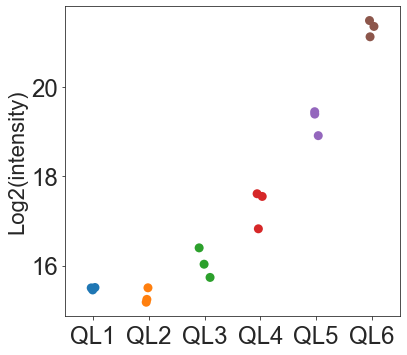

In [28]:
import seaborn as sns
plt.rcParams['font.family'] = 'Arial'

plt.figure(figsize=(6, 5.7), edgecolor='#04253a')
g=sns.stripplot(x='type', y="lipid_711", data=new_dflog2, jitter=True,size=9) 
g.tick_params(axis='x', which='major',labelsize=24, pad=5)
g.tick_params(axis='y', which='major',labelsize=24)
plt.xlabel('')
plt.ylabel('Log2(intensity)', fontsize=22)
    
#plt.savefig(r'D:\\project7_SMAD\\figure2\\quantification\\%s.svg' % savename,dpi=800,bbox_inches='tight')
plt.show()

In [18]:
plt738=[new_dflog2.iloc[:3,:5].mean().tolist()[1],new_dflog2.iloc[3:6,:5].mean().tolist()[1],
new_dflog2.iloc[6:9,:5].mean().tolist()[1],new_dflog2.iloc[9:12,:5].mean().tolist()[1],
new_dflog2.iloc[12:15,:5].mean().tolist()[1],new_dflog2.iloc[15:18,:5].mean().tolist()[1]]



In [19]:
plt753=[new_dflog2.iloc[:3,:5].mean().tolist()[2],new_dflog2.iloc[3:6,:5].mean().tolist()[2],
new_dflog2.iloc[6:9,:5].mean().tolist()[2],new_dflog2.iloc[9:12,:5].mean().tolist()[2],
new_dflog2.iloc[12:15,:5].mean().tolist()[2],new_dflog2.iloc[15:18,:5].mean().tolist()[2]]



In [20]:
plt529=[new_dflog2.iloc[:3,:5].mean().tolist()[4],new_dflog2.iloc[3:6,:5].mean().tolist()[4],
new_dflog2.iloc[6:9,:5].mean().tolist()[4],new_dflog2.iloc[9:12,:5].mean().tolist()[4],
new_dflog2.iloc[12:15,:5].mean().tolist()[4],new_dflog2.iloc[15:18,:5].mean().tolist()[4]]


In [21]:
new_dflog2.T

,QL1_1,QL1_2,QL1_3,QL2_1,QL2_2,QL2_3,QL3_1,QL3_2,QL3_3,QL4_1,QL4_2,QL4_3,QL5_1,QL5_2,QL5_3,QL6_1,QL6_2,QL6_3
lipid_name,,,,,,,,,,,,,,,,,,
lipid_711,16.698945,17.309041,16.742011,16.706317,16.912474,16.726297,18.305586,18.357415,18.125841,19.89917,19.912437,19.692157,20.708372,20.737457,21.127072,21.675541,21.709586,21.520163
lipid_738,18.041783,18.209729,17.498298,19.882752,20.290233,20.085928,21.937131,21.997125,21.791923,23.627805,23.590793,23.445392,24.553363,24.615318,25.0877,25.824491,25.830112,25.687142
lipid_753,21.1341,20.924999,20.697808,22.88145,23.314568,23.203254,25.302841,25.349738,25.228366,27.089847,27.018525,26.942069,28.028371,28.143199,28.587625,29.331156,29.247366,29.078562
lipid_781,14.594309,19.249958,17.586158,16.769641,14.743697,14.768141,15.62237,15.663781,15.448715,17.751604,17.826081,17.723593,19.191574,19.246968,19.67181,20.430431,20.309295,20.078857
lipid_529,19.231687,19.511097,18.972948,21.449759,21.74629,21.55099,23.911407,23.891671,23.757046,26.033271,25.908418,25.802755,27.27137,27.159159,27.679777,28.623869,28.522507,28.004541
type,QL1,QL1,QL1,QL2,QL2,QL2,QL3,QL3,QL3,QL4,QL4,QL4,QL5,QL5,QL5,QL6,QL6,QL6


In [24]:
def getlipid_inten_all(mzmls=mzmls_0,num=0,name='QL0'):
    tmp_00= pyteomics.mzml.read(mzmls[num], use_index=True)
    sum_711=[]
    sum_738=[]
    sum_753=[]
    sum_529=[]
    sum_781=[]
    # change the numbers below if your lipid scans are different
    for i in range(50,300):
        if (float(tmp_00.get_by_index(i)['base peak m/z'])>710) & (float(tmp_00.get_by_index(i)['base peak m/z'])<713):
            sum_711.append(int(tmp_00.get_by_index(i)['base peak intensity']))
        if (float(tmp_00.get_by_index(i)['base peak m/z'])>737) & (float(tmp_00.get_by_index(i)['base peak m/z'])<740):
            sum_738.append(int(tmp_00.get_by_index(i)['base peak intensity']))
        if (float(tmp_00.get_by_index(i)['base peak m/z'])>753) & (float(tmp_00.get_by_index(i)['base peak m/z'])<754):
            sum_753.append(int(tmp_00.get_by_index(i)['base peak intensity']))
        if (float(tmp_00.get_by_index(i)['base peak m/z'])>527) & (float(tmp_00.get_by_index(i)['base peak m/z'])<530):
            sum_529.append(int(tmp_00.get_by_index(i)['base peak intensity'])) 
        if (float(tmp_00.get_by_index(i)['base peak m/z'])>780) & (float(tmp_00.get_by_index(i)['base peak m/z'])<783):
            sum_781.append(int(tmp_00.get_by_index(i)['base peak intensity']))  
    dict_lipid={'lipid_711':sum_711,'lipid_738':sum_738,'lipid_753':sum_753,'lipid_781':sum_781,'lipid_529':sum_529}
    df = pd.DataFrame.from_dict(dict_lipid, orient='index')
    df = df.transpose()
    return(df)
def dict_lipinten_all(mzmls=mzmls_0,num=0,name='QL0'):
    tmp_00= pyteomics.mzml.read(mzmls[num], use_index=True)
    sum_711=[]
    sum_738=[]
    sum_753=[]
    sum_529=[]
    sum_781=[]
    # change the numbers below if your lipid scans are different
    for i in range(50,300):
        if (float(tmp_00.get_by_index(i)['base peak m/z'])>710) & (float(tmp_00.get_by_index(i)['base peak m/z'])<713):
            sum_711.append(int(tmp_00.get_by_index(i)['base peak intensity']))
        if (float(tmp_00.get_by_index(i)['base peak m/z'])>737) & (float(tmp_00.get_by_index(i)['base peak m/z'])<740):
            sum_738.append(int(tmp_00.get_by_index(i)['base peak intensity']))
        if (float(tmp_00.get_by_index(i)['base peak m/z'])>753) & (float(tmp_00.get_by_index(i)['base peak m/z'])<754):
            sum_753.append(int(tmp_00.get_by_index(i)['base peak intensity']))
        if (float(tmp_00.get_by_index(i)['base peak m/z'])>527) & (float(tmp_00.get_by_index(i)['base peak m/z'])<530):
            sum_529.append(int(tmp_00.get_by_index(i)['base peak intensity'])) 
        if (float(tmp_00.get_by_index(i)['base peak m/z'])>780) & (float(tmp_00.get_by_index(i)['base peak m/z'])<783):
            sum_781.append(int(tmp_00.get_by_index(i)['base peak intensity']))  
    dict_lipid={'lipid_711':sum_711,'lipid_738':sum_738,'lipid_753':sum_753,'lipid_781':sum_781,'lipid_529':sum_529}
    return(dict_lipid)

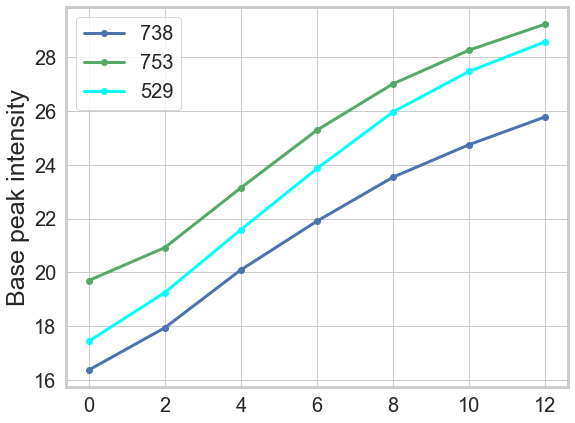

In [281]:
import seaborn as sns
sns.set(font_scale=2)
sns.set_style("whitegrid")
matplotlib.rcParams['font.family'] = "Arial"
matplotlib.rcParams['axes.linewidth'] = 3


plt.figure(figsize=(9,7))

#plt.plot(aa,datay1.iloc[0,:],'r',label='711',marker='o',linewidth=3)
plt.plot(aa,datay.iloc[1,:],'b',label='738',marker='o',linewidth=3)
plt.plot(aa,datay.iloc[2,:],'g',label='753',marker='o',linewidth=3)
#plt.plot(aa,datay1.iloc[3,:],'black',label='781',marker='o',linewidth=3)
plt.plot(aa,datay.iloc[4,:],'cyan',label='529',marker='o',linewidth=3)
#plt.xlabel('Concentration',fontsize=25)
plt.ylabel('Base peak intensity',fontsize=25)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)

plt.legend(fontsize=20)
plt.show()

# quantification of QCAL standards starts from this cell

In [76]:
# set the m/z for each target peptide of QCAL proteins 

peptide_list=[525.84,721.84,802.84,749.82,778.32,634.33,671.80,707.30,721.30,737.32]

In [77]:
seq_list=['ALVALVLVPR',
'VLYPNDNFFEGK',
'AVMMMDDFAAFVEK',
'GGVNDNEEGFFSAR',
'GGGVNDNEEGFFSAR',
'YLGYLEQLLR',
'AVMDDFAAFVEK',
'GVNDNEEGFFSAK',
'GVNDNEEGFFSAR',
'AVMMDDFAAFVEK',]

In [78]:
# define a function to get theoretical fragments and its corresponding m/z from a peptide sequence 

def getfrag(sequence = 'DRVYIHPFHL' ):
    customAAcomp = dict(mass.std_aa_comp)
    customAAcomp['C'] = mass.Composition({'H':8, 'C':5, 'S':1,'O':2, 'N': 2}) ## add carbamidomethyl to the modifications
    customAAcomp['m'] = mass.Composition({'H': 9, 'C': 5, 'S': 1, 'O': 2, 'N': 1}) ## add oxidized methionine
    protonmass = mass.calculate_mass(formula='H')-0.00054858 ## mass of hydrogen minus an electron  
    # clean sequence to remove mod masses and change oxMet to 'm'
    fraglist=[]
    z=1
    for x in range(1, len(sequence)-1):
        fragseq_y = sequence[x:]
        fragseq_b = sequence[:x]
        lightfragmz_y = mass.calculate_mass(sequence=sequence[x:], ion_type='y', charge=1, aa_comp = customAAcomp)
        lightfragmz_b = mass.calculate_mass(sequence=sequence[:x], ion_type='b', charge=1, aa_comp = customAAcomp)
        ## part to count the number of K and R residues
        fraglist.append([fragseq_y, lightfragmz_y,fragseq_b,lightfragmz_b])   
    return(fraglist)
# to extract the int values between two other values,  the value range was set according to ppm 
def getFragInt(pred_mass, mz_list, int_list, tol, tol_type):
    ''' 
    PURPOSE:
    Find observed intensity for theoretical m/z value in spectra
    
    INPUTS:
    pred_mass = the theoretical mass of the fragment ion
    mz_array = numpy array of all peak masses in the spectra
    int_array = numpy array of all peak intensities in the spectra
    ppm = the mass tolerance for the fragments in ppm
    noiselevel = value to be subtracted from each value
    
    OUTPUTS:
    numpy array containing the intensity for any m/z found
    
    '''
    if tol_type=="ppm":
        lowmz = pred_mass - pred_mass*tol
        highmz = pred_mass + pred_mass*tol
    if tol_type == "abs":
        lowmz = pred_mass - tol
        highmz = pred_mass + tol
    found = [int_list[index] for index, value in enumerate(mz_list) if value>lowmz and value<highmz]
    #found = found-noiselevel
    if len(found)==0:
        found = [1]
    return(found[0])
customAAcomp = dict(mass.std_aa_comp)
customAAcomp['C'] = mass.Composition({'H':8, 'C':5, 'S':1,'O':2, 'N': 2}) ## add carbamidomethyl to the modifications
customAAcomp['m'] = mass.Composition({'H': 9, 'C': 5, 'S': 1, 'O': 2, 'N': 1}) ## add oxidized methionine
protonmass = mass.calculate_mass(formula='H')-0.00054858 ## mass of hydrogen minus an electron

In [79]:
# get the m/z list of y fragments
def yion_mz(tmp_pep=seq_list[0]):
    fraglist = []
    z=1
    for x in range(1, len(tmp_pep)-1):
        fragseq = tmp_pep[x:]
        lightfragmz = mass.calculate_mass(sequence=tmp_pep[x:], ion_type='y', charge=1, aa_comp = customAAcomp)
        ## part to count the number of K and R residues
        fraglist.append([fragseq, lightfragmz])
    fl = pd.DataFrame(fraglist)
    fl.columns = ['fragseq', 'lightmz']
    return(fl)

In [109]:
mzmls_4[2].split('\\')[-1]

'QL4_3.mzML'

In [110]:
# take the aveage intensity of the ten peptides in each file

def get_qcal(files=mzmls_1,listnum=0):
    tmp11 = pyteomics.mzml.read(files[listnum], use_index=True)
    fragment_ions = {525.8: seq_list[0],721.8: seq_list[1],802.9: seq_list[2],
                     778.3: seq_list[3],749.8: seq_list[4],634.3: seq_list[5],
                     671.8: seq_list[6],707.3: seq_list[7],721.3: seq_list[8],
                     737.3: seq_list[9]}
    tol_type = "ppm"
    tol = 5e-6
    quan_lists = [[] for _ in range(10)]
    for number in range(220, 510):
        tmpmzarray = tmp11.get_by_index(number)["m/z array"].tolist()
        tmpintarray = tmp11.get_by_index(number)["intensity array"].tolist()
        precursor_mz = round(float(tmp11.get_by_index(number)["precursorList"]["precursor"][0]["selectedIonList"]["selectedIon"][0]["selected ion m/z"]), 1)
        if precursor_mz in fragment_ions:
            fragment_seq = fragment_ions[precursor_mz]
            ints = [getFragInt(x, tmpmzarray, tmpintarray, tol, tol_type) for x in yion_mz(tmp_pep=fragment_seq)["lightmz"]]
            quan_lists[list(fragment_ions.keys()).index(precursor_mz)].append(sum(ints))
    sup=files[listnum].split('\\')[-1]
    dict_new={seq_list[0]+sup: quan_lists[0][:10],seq_list[1]+sup: quan_lists[1][:10],seq_list[2]+sup: quan_lists[2][:10],
              seq_list[3]+sup: quan_lists[3][:10],seq_list[4]+sup: quan_lists[4][:10],seq_list[5]+sup: quan_lists[5][:10],
              seq_list[6]+sup: quan_lists[6][:10],seq_list[7]+sup: quan_lists[7][:10],
             seq_list[8]+sup: quan_lists[8][:10],seq_list[9]+sup: quan_lists[9][:10],}
    df = pd.DataFrame(dict_new)
    #df.set_index('sequence',inplace=True)
    return(df)

In [111]:
get_qcal(files=mzmls_1,listnum=0)

,ALVALVLVPRQL1_2.mzML,VLYPNDNFFEGKQL1_2.mzML,AVMMMDDFAAFVEKQL1_2.mzML,GGVNDNEEGFFSARQL1_2.mzML,GGGVNDNEEGFFSARQL1_2.mzML,YLGYLEQLLRQL1_2.mzML,AVMDDFAAFVEKQL1_2.mzML,GVNDNEEGFFSAKQL1_2.mzML,GVNDNEEGFFSARQL1_2.mzML,AVMMDDFAAFVEKQL1_2.mzML
0,65522.562500,6629.127380,4196.839783,29500.352295,22095.329895,30322.338379,31654.561401,28199.484436,9033.332703,12913.520752
1,49690.246826,9039.926758,3991.310364,34564.955811,28327.223511,37882.092773,31148.496277,32141.113770,10399.829224,4578.151917
2,62033.569824,14666.882263,4065.097595,31523.841553,27970.682739,35577.726074,27861.336914,30329.722168,12080.037231,10707.604858
3,64169.674561,13208.324341,4302.582245,34407.074463,26297.036987,34535.087891,34858.578613,28037.019409,10569.625366,14033.780396
4,67580.928711,10406.804779,2334.059692,34989.678223,24292.714722,25397.837158,33540.738037,29161.686768,8962.077515,13768.975342
5,68731.324707,10361.004272,2502.814453,37884.523682,22006.904053,26199.448242,26256.751221,31843.277588,10857.065308,10750.211304
6,62368.925781,6159.572021,3113.811401,43963.172607,29440.666382,17590.778809,26129.599854,30183.027466,11180.819336,10017.645752
7,53533.720703,12620.229370,3820.693054,39560.952393,29365.263489,29112.864258,31215.977295,27846.430054,9469.614929,10970.458069
8,52147.477051,10126.793884,4338.521790,36149.172729,29315.567139,23699.730469,31892.042480,30841.287781,11564.371216,13335.691040
9,59681.961426,14094.703857,1533.981873,30949.963867,32131.316772,30605.499512,32045.720825,30230.739380,11519.597290,9894.472290


In [114]:
dfpro_QL1=pd.concat([get_qcal(files=mzmls_1,listnum=0),
                 get_qcal(files=mzmls_1,listnum=1),
                  get_qcal(files=mzmls_1,listnum=2)], axis=1)
dfpro_QL2=pd.concat([get_qcal(files=mzmls_2,listnum=0),
                 get_qcal(files=mzmls_2,listnum=1),
                  get_qcal(files=mzmls_2,listnum=2)], axis=1)
dfpro_QL3=pd.concat([get_qcal(files=mzmls_3,listnum=0),
                 get_qcal(files=mzmls_3,listnum=1),
                  get_qcal(files=mzmls_3,listnum=2)], axis=1)
dfpro_QL4=pd.concat([get_qcal(files=mzmls_4,listnum=0),
                 get_qcal(files=mzmls_4,listnum=1),
                  get_qcal(files=mzmls_4,listnum=2)], axis=1)
dfpro_QL5=pd.concat([get_qcal(files=mzmls_5,listnum=0),
                 get_qcal(files=mzmls_5,listnum=1),
                  get_qcal(files=mzmls_5,listnum=2)], axis=1)
dfpro_QL6=pd.concat([get_qcal(files=mzmls_6,listnum=0),
                 get_qcal(files=mzmls_6,listnum=1),
                  get_qcal(files=mzmls_6,listnum=2)], axis=1)

In [115]:
dfpro_all=pd.concat([dfpro_QL1,dfpro_QL2,dfpro_QL3,dfpro_QL4,dfpro_QL5,dfpro_QL6],axis=1)

In [116]:
dfpro_all

,ALVALVLVPRQL1_2.mzML,VLYPNDNFFEGKQL1_2.mzML,AVMMMDDFAAFVEKQL1_2.mzML,GGVNDNEEGFFSARQL1_2.mzML,GGGVNDNEEGFFSARQL1_2.mzML,YLGYLEQLLRQL1_2.mzML,AVMDDFAAFVEKQL1_2.mzML,GVNDNEEGFFSAKQL1_2.mzML,GVNDNEEGFFSARQL1_2.mzML,AVMMDDFAAFVEKQL1_2.mzML,...,ALVALVLVPRQL6.mzML,VLYPNDNFFEGKQL6.mzML,AVMMMDDFAAFVEKQL6.mzML,GGVNDNEEGFFSARQL6.mzML,GGGVNDNEEGFFSARQL6.mzML,YLGYLEQLLRQL6.mzML,AVMDDFAAFVEKQL6.mzML,GVNDNEEGFFSAKQL6.mzML,GVNDNEEGFFSARQL6.mzML,AVMMDDFAAFVEKQL6.mzML
0,65522.562500,6629.127380,4196.839783,29500.352295,22095.329895,30322.338379,31654.561401,28199.484436,9033.332703,12913.520752,...,3.293807e+07,3.383640e+06,9.780810e+05,2.141455e+07,9.744251e+06,1.867807e+07,6.860657e+06,3.981106e+06,4.063363e+06,4.594036e+06
1,49690.246826,9039.926758,3991.310364,34564.955811,28327.223511,37882.092773,31148.496277,32141.113770,10399.829224,4578.151917,...,3.848075e+07,3.495698e+06,1.018044e+06,2.129858e+07,1.363551e+07,1.832651e+07,6.860531e+06,4.217006e+06,5.699600e+06,4.966878e+06
2,62033.569824,14666.882263,4065.097595,31523.841553,27970.682739,35577.726074,27861.336914,30329.722168,12080.037231,10707.604858,...,3.336907e+07,3.534906e+06,4.493572e+05,2.218047e+07,1.398387e+07,1.786439e+07,7.025935e+06,4.341609e+06,5.244297e+06,5.194094e+06
3,64169.674561,13208.324341,4302.582245,34407.074463,26297.036987,34535.087891,34858.578613,28037.019409,10569.625366,14033.780396,...,3.736162e+07,3.499789e+06,9.437782e+05,2.156126e+07,1.390641e+07,1.906384e+07,7.655291e+06,4.328640e+06,5.381455e+06,5.107956e+06
4,67580.928711,10406.804779,2334.059692,34989.678223,24292.714722,25397.837158,33540.738037,29161.686768,8962.077515,13768.975342,...,3.535748e+07,3.984778e+06,1.060714e+06,2.201173e+07,1.365164e+07,1.842948e+07,8.078457e+06,4.326165e+06,5.504300e+06,5.249864e+06
5,68731.324707,10361.004272,2502.814453,37884.523682,22006.904053,26199.448242,26256.751221,31843.277588,10857.065308,10750.211304,...,3.558396e+07,3.439881e+06,1.066452e+06,2.072090e+07,1.255136e+07,2.106330e+07,7.327566e+06,4.231477e+06,5.353056e+06,4.876128e+06
6,62368.925781,6159.572021,3113.811401,43963.172607,29440.666382,17590.778809,26129.599854,30183.027466,11180.819336,10017.645752,...,3.017480e+07,3.325449e+06,1.079228e+06,2.215155e+07,1.126260e+07,1.802719e+07,7.134426e+06,4.391843e+06,5.260064e+06,5.105753e+06
7,53533.720703,12620.229370,3820.693054,39560.952393,29365.263489,29112.864258,31215.977295,27846.430054,9469.614929,10970.458069,...,3.183814e+07,3.301685e+06,9.806099e+05,2.232330e+07,1.326283e+07,1.854954e+07,7.498776e+06,4.335218e+06,5.920363e+06,5.133939e+06
8,52147.477051,10126.793884,4338.521790,36149.172729,29315.567139,23699.730469,31892.042480,30841.287781,11564.371216,13335.691040,...,3.194125e+07,3.445745e+06,1.042231e+06,2.078111e+07,1.244488e+07,1.813013e+07,7.512107e+06,3.965358e+06,5.007267e+06,5.105076e+06
9,59681.961426,14094.703857,1533.981873,30949.963867,32131.316772,30605.499512,32045.720825,30230.739380,11519.597290,9894.472290,...,3.793295e+07,3.444211e+06,1.063751e+06,2.161102e+07,1.260752e+07,1.958806e+07,7.012569e+06,4.177524e+06,6.124580e+06,4.916186e+06


In [117]:
qcs=np.log2(dfpro_all.filter(like='ALVALVLVPR'))

In [119]:
len(qcs.columns)

18

In [120]:
def getdfpro(name='ALVALVLVPR'):
    kld=np.log2(dfpro_all.filter(like=name))
    j1=kld.iloc[:,:3].values.tolist()
    j2=kld.iloc[:,3:6].values.tolist()
    j3=kld.iloc[:,6:9].values.tolist()
    j4=kld.iloc[:,9:12].values.tolist()
    j5=kld.iloc[:,12:15].values.tolist()
    j6=kld.iloc[:,15:18].values.tolist()
    new_list1 = [item for sublist in j1 for item in sublist]
    new_list2 = [item for sublist in j2 for item in sublist]
    new_list3 = [item for sublist in j3 for item in sublist]
    new_list4 = [item for sublist in j4 for item in sublist]
    new_list5 = [item for sublist in j5 for item in sublist]
    new_list6 = [item for sublist in j6 for item in sublist]
    protein={'QL1':new_list1,'QL2':new_list2,'QL3':new_list3,'QL4':new_list4,'QL5':new_list5,'QL6':new_list6}
    df=pd.DataFrame(protein)
    return(df)

In [121]:
getdfpro(name='ALVALVLVPR')

,QL1,QL2,QL3,QL4,QL5,QL6
0,15.999704,17.155755,19.006370,20.990395,23.106221,25.608061
1,15.322320,17.240025,19.214726,21.176309,23.454086,25.683568
2,15.959268,17.202751,19.419015,21.401311,23.398512,24.973253
3,15.600675,16.899005,18.901656,21.014223,22.929980,25.428865
4,15.460354,17.391521,19.135508,21.548852,23.395674,25.397927
5,15.684358,17.197340,19.457902,21.402893,23.379311,25.197634
6,15.920762,16.903781,18.972735,20.928721,23.023785,25.446620
7,15.510243,17.571253,19.189082,21.288553,23.586997,25.539063
8,15.883541,17.028588,19.213482,21.398755,23.487380,24.992008
9,15.969604,16.992428,18.924797,20.993943,23.042970,25.510608


In [ ]:
seq_list=['ALVALVLVPR',
'VLYPNDNFFEGK',
'AVMMMDDFAAFVEK',
'GGVNDNEEGFFSAR',
'GGGVNDNEEGFFSAR',
'YLGYLEQLLR',
'AVMDDFAAFVEK',
'GVNDNEEGFFSAK',
'GVNDNEEGFFSAR',
'AVMMDDFAAFVEK',]

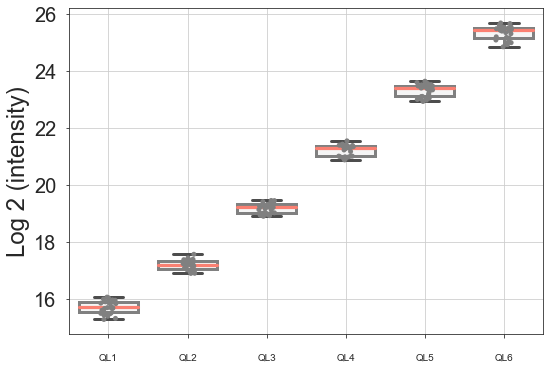

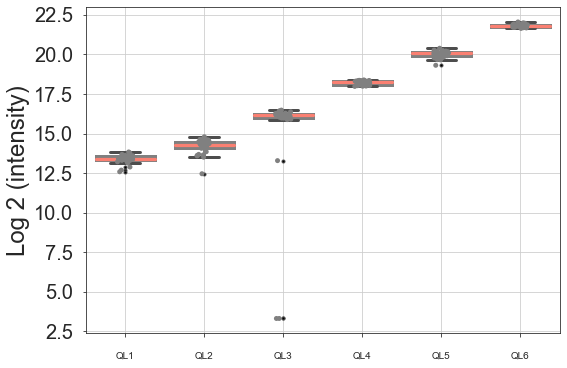

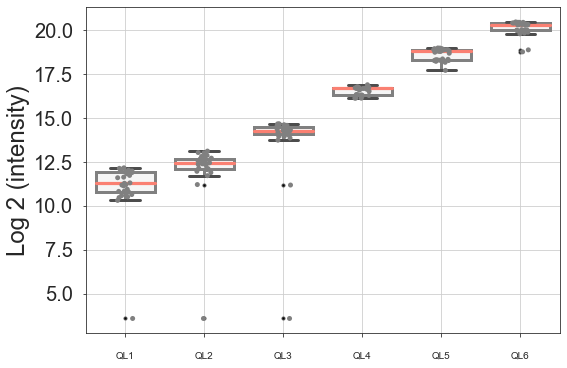

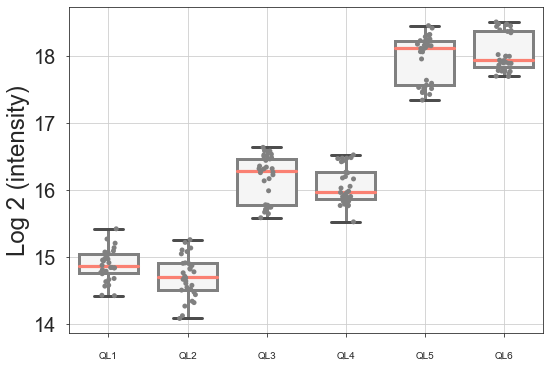

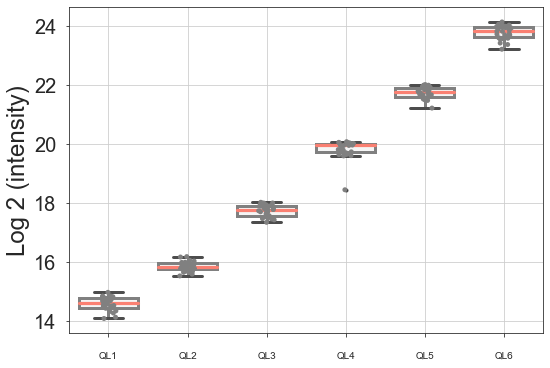

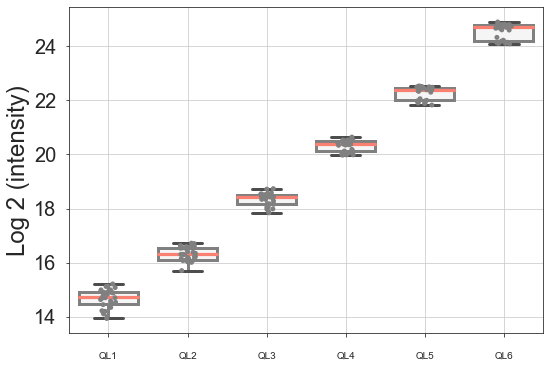

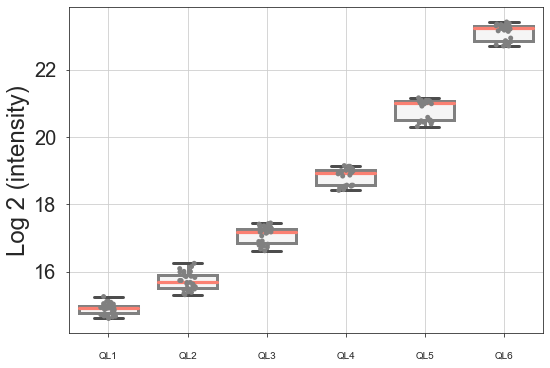

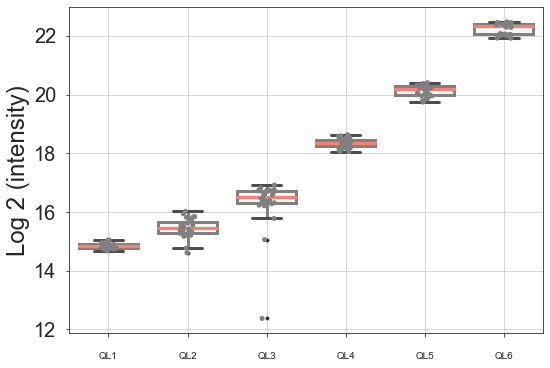

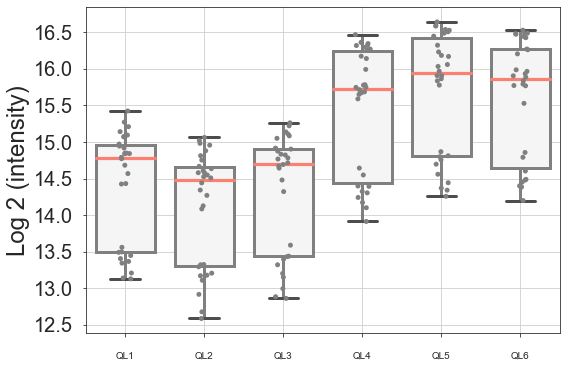

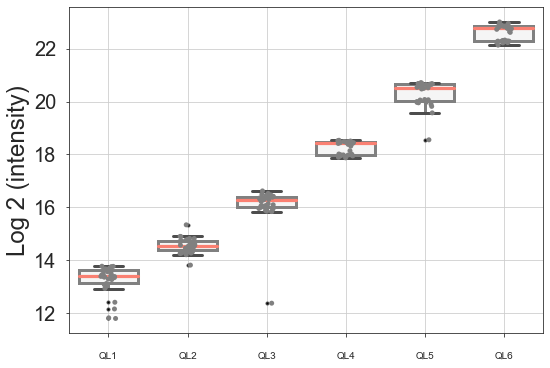

In [131]:
# Plot all common peptides after take log10 
for nameindex in seq_list:
    matplotlib.rcParams['font.family'] = "Arial"
    plt.figure(figsize=(8.5, 6))
    sns.boxplot(data=getdfpro(name=nameindex), orient='v',color="grey", boxprops=dict(facecolor="whitesmoke",edgecolor='grey',linewidth=3), 
                whiskerprops=dict(color="grey",linewidth=3), medianprops=dict(color="salmon",linewidth=3.2), width=0.75,fliersize=6,
               flierprops=dict(markerfacecolor="black", marker="."),linewidth=3)
    sns.stripplot(data=getdfpro(name=nameindex), color="grey")
    #plt.rc('xtick', labelsize=12, fontfamily='Arial')
    #plt.rc('ytick', labelsize=12, fontfamily='Arial')
    plt.ylabel('Log 2 (intensity)',fontsize=24)
    plt.tick_params(axis='x', which='major', pad=15)
    plt.tick_params(axis='y', which='major', pad=9)
    plt.xticks(fontsize=10)
    plt.yticks(fontsize=20)
    #plt.ylim(3.5,7.5)
    plt.grid()
    plt.savefig(r'D:\\project7_SMAD\\figure2\\quantification\\%s.svg' % nameindex,dpi=800,bbox_inches='tight')
    plt.show()

In [ ]:

def get_qcal_inten(files=mzmls_1,listnum=0):
    tmp11 = pyteomics.mzml.read(files[listnum], use_index=True)
    fragment_ions = {525.8: seq_list[0],721.8: seq_list[1],802.9: seq_list[2],
                     778.3: seq_list[3],749.8: seq_list[4],634.3: seq_list[5],
                     671.8: seq_list[6],707.3: seq_list[7],721.3: seq_list[8],
                     737.3: seq_list[9]}
    tol_type = "ppm"
    tol = 5e-6
    quan_lists = [[] for _ in range(10)]
    for number in range(220, 510):
        tmpmzarray = tmp11.get_by_index(number)["m/z array"].tolist()
        tmpintarray = tmp11.get_by_index(number)["intensity array"].tolist()
        precursor_mz = round(float(tmp11.get_by_index(number)["precursorList"]["precursor"][0]["selectedIonList"]["selectedIon"][0]["selected ion m/z"]), 1)
        if precursor_mz in fragment_ions:
            fragment_seq = fragment_ions[precursor_mz]
            ints = [getFragInt(x, tmpmzarray, tmpintarray, tol, tol_type) for x in yion_mz(tmp_pep=fragment_seq)["lightmz"]]
            quan_lists[list(fragment_ions.keys()).index(precursor_mz)].append(sum(ints))
    made=[]
    for i in range(10):
        made.append(sum(quan_lists[i])/len(quan_lists[i]))  
    # Construct column name dynamically using string formatting
    column_name = 's{}'.format(files[listnum])
    dict_new={'sequence': seq_list, column_name: made}
    df = pd.DataFrame(dict_new)
    df.set_index('sequence',inplace=True)
    return(df)

In [31]:
qcal_df=pd.concat([get_qcal_inten(files=mzmls_1,listnum=0),get_qcal_inten(files=mzmls_1,listnum=1),get_qcal_inten(files=mzmls_1,listnum=2),
          get_qcal_inten(files=mzmls_2,listnum=0),get_qcal_inten(files=mzmls_2,listnum=1),get_qcal_inten(files=mzmls_2,listnum=2),
          get_qcal_inten(files=mzmls_3,listnum=0),get_qcal_inten(files=mzmls_3,listnum=1),get_qcal_inten(files=mzmls_3,listnum=2),
          get_qcal_inten(files=mzmls_4,listnum=0),get_qcal_inten(files=mzmls_4,listnum=1),get_qcal_inten(files=mzmls_4,listnum=2),
          get_qcal_inten(files=mzmls_5,listnum=0),get_qcal_inten(files=mzmls_5,listnum=1),get_qcal_inten(files=mzmls_5,listnum=2),
          get_qcal_inten(files=mzmls_6,listnum=0),get_qcal_inten(files=mzmls_6,listnum=1),get_qcal_inten(files=mzmls_6,listnum=2)], axis=1)
        
            

In [32]:
qcal=qcal_df.T
qcal_log2=np.log2(qcal)

In [33]:
qcal_log2.iloc[:3,:].sem().tolist()[0]

0.3848100240968856

In [34]:
def listmean(i=0):  
    qcal=[qcal_log2.iloc[:3,:].mean().tolist()[i],
    qcal_log2.iloc[3:6,:].mean().tolist()[i],
    qcal_log2.iloc[6:7,:].mean().tolist()[i],
    qcal_log2.iloc[9:12,:].mean().tolist()[i],
    qcal_log2.iloc[12:15,:].mean().tolist()[i],
    qcal_log2.iloc[15:18,:].mean().tolist()[i]]
    return(qcal)
def listerror(i=0):  
    qcal=[qcal_log2.iloc[:3,:].sem().tolist()[i],
    qcal_log2.iloc[3:6,:].sem().tolist()[i],
    qcal_log2.iloc[6:7,:].sem().tolist()[i],
    qcal_log2.iloc[9:12,:].sem().tolist()[i],
    qcal_log2.iloc[12:15,:].sem().tolist()[i],
    qcal_log2.iloc[15:18,:].sem().tolist()[i]]
    return(qcal)

In [35]:
listmean(i=2)

[14.23287814066545,
 15.816932716313339,
 18.299424354561847,
 20.100979319856563,
 21.481613244274996,
 21.93796129140433]

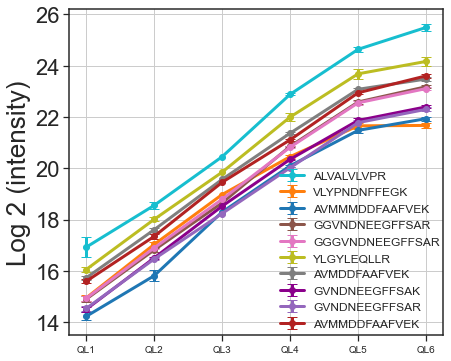

In [37]:
from matplotlib import pyplot
import matplotlib
import seaborn as sns
from matplotlib.font_manager import FontProperties
sns.set_theme(style="ticks")
plt.figure(figsize=(6.7,6),edgecolor="#04253a")
matplotlib.rcParams['font.family'] = "Arial"

matplotlib.rcParams['axes.linewidth'] = 1.5



plt.errorbar(AA,listmean(i=0),yerr=listerror(i=0),color='tab:cyan',label=seq_list[0],marker='o',linewidth=3,capsize=5)
plt.errorbar(AA,listmean(i=1),yerr=listerror(i=1),color='tab:orange',label=seq_list[1],marker='o',linewidth=3,capsize=5)
plt.errorbar(AA,listmean(i=2),yerr=listerror(i=2),color='tab:blue',label=seq_list[2],marker='o',linewidth=3,capsize=5)
plt.errorbar(AA,listmean(i=3),yerr=listerror(i=3),color='tab:brown',label=seq_list[3],marker='o',linewidth=3,capsize=5)
plt.errorbar(AA,listmean(i=4),yerr=listerror(i=4),color='tab:pink',label=seq_list[4],marker='o',linewidth=3,capsize=5)
plt.errorbar(AA,listmean(i=5),yerr=listerror(i=5),color='tab:olive',label=seq_list[5],marker='o',linewidth=3,capsize=5)
plt.errorbar(AA,listmean(i=6),yerr=listerror(i=6),color='tab:gray',label=seq_list[6],marker='o',linewidth=3,capsize=5)
plt.errorbar(AA,listmean(i=7),yerr=listerror(i=7),color='darkmagenta',label=seq_list[7],marker='o',linewidth=3,capsize=5)
plt.errorbar(AA,listmean(i=8),yerr=listerror(i=8),color='tab:purple',label=seq_list[8],marker='o',linewidth=3,capsize=5)
plt.errorbar(AA,listmean(i=9),yerr=listerror(i=9),color='firebrick',label=seq_list[9],marker='o',linewidth=3,capsize=5)

plt.legend(fontsize=12,loc=(0.55, 0.005),frameon=False)
plt.ylabel('Log 2 (intensity)',fontsize=26)
plt.xticks(fontsize=10)
plt.yticks(fontsize=22)
plt.grid()

plt.savefig('D:\\project7_SMAD\\figure2\\Figure2_H.svg', dpi=800,bbox_inches = 'tight')


In [35]:
sum(qqq)/len(qqq)

18176.55873260498

In [ ]:
results_dict[file.split('\\')[-1]] = sum(ints)       

In [217]:
tmpmzarray = tmp11.get_by_index(365)['m/z array'].tolist()
tmpintarray = tmp11.get_by_index(365)['intensity array'].tolist()

In [ ]:
for file in mzmls_1:
    print(file.split('\\')[-1])
    tmp_indexes=[]
    with pyteomics.mzml.read(file, use_index=True) as tmpquantfile:
        #index_diff = 167-int(tmpquantfile.get_by_index(0)['id'][-3:])
        for scannumber in 
        index = getpepdf(num=0).scan[i]
        print(index)
        tmpmzarray = tmpquantfile.get_by_index(index)['m/z array'].tolist()
        tmpintarray = tmpquantfile.get_by_index(index)['intensity array'].tolist()
        ints = [getFragInt(x, tmpmzarray, tmpintarray, TOL, TOL_TYPE) for x in fl['lightmz'] ]
        print(sum(ints))
    results_dict[file.split('\\')[-1]] = sum(ints)
    results_dict['scan'] = index

In [189]:
getfrag(sequence = 'DRVYIHPFHL' )

[['RVYIHPFHL', 1181.6578240526098, 'D', 116.0342194906],
 ['VYIHPFHL', 1025.55671302901, 'DR', 272.1353305142],
 ['YIHPFHL', 926.48829911602, 'DRV', 371.20374442719003],
 ['IHPFHL', 763.42497058347, 'DRVY', 534.2670729597401],
 ['HPFHL', 650.34090660634, 'DRVYI', 647.35113693687],
 ['PFHL', 513.28199474789, 'DRVYIH', 784.41004879532],
 ['FHL', 416.22923089904003, 'DRVYIHP', 881.4628126441701],
 ['HL', 269.16081698605, 'DRVYIHPF', 1028.53122655716]]

In [ ]:

tol_type = "ppm"
tol = 5e-6
results_dict = {}
index_dict = {}
tmp11=pyteomics.mzml.read(mzmls_1[0], use_index=True)
quan1,quan2,quan3,quan4,quan5,quan6,quan7,quan8,quan9,quan10=[],[],[],[],[],[],[],[],[],[]
for number in range(310,660):
    if number in range(310,370):
        tmpmzarray = tmp11.get_by_index(number)['m/z array'].tolist()
        tmpintarray = tmp11.get_by_index(number)['intensity array'].tolist()
        if round(float(tmp11.get_by_index(number)['precursorList']['precursor'][0]['selectedIonList']['selectedIon'][0]['selected ion m/z']),1)==525.8:
            ints = [getFragInt(x, tmpmzarray, tmpintarray, tol, tol_type) for x in yion_mz(tmp_pep=seq_list[0])['lightmz']]
            quan1.append(sum(ints))
        if round(float(tmp11.get_by_index(number)['precursorList']['precursor'][0]['selectedIonList']['selectedIon'][0]['selected ion m/z']),1)==721.8:
            ints = [getFragInt(x, tmpmzarray, tmpintarray, tol, tol_type) for x in yion_mz(tmp_pep=seq_list[1])['lightmz']]
            quan2.append(sum(ints))
        if round(float(tmp11.get_by_index(number)['precursorList']['precursor'][0]['selectedIonList']['selectedIon'][0]['selected ion m/z']),1)==802.9:
            ints = [getFragInt(x, tmpmzarray, tmpintarray, tol, tol_type) for x in yion_mz(tmp_pep=seq_list[2])['lightmz']]
            quan3.append(sum(ints))        
    if number in range(420,480):
        tmpmzarray = tmp11.get_by_index(number)['m/z array'].tolist()
        tmpintarray = tmp11.get_by_index(number)['intensity array'].tolist()
        if round(float(tmp11.get_by_index(number)['precursorList']['precursor'][0]['selectedIonList']['selectedIon'][0]['selected ion m/z']),1)==778.3:
            ints = [getFragInt(x, tmpmzarray, tmpintarray, tol, tol_type) for x in yion_mz(tmp_pep=seq_list[3])['lightmz']]
            quan4.append(sum(ints))
        if round(float(tmp11.get_by_index(number)['precursorList']['precursor'][0]['selectedIonList']['selectedIon'][0]['selected ion m/z']),1)==749.8:
            ints = [getFragInt(x, tmpmzarray, tmpintarray, tol, tol_type) for x in yion_mz(tmp_pep=seq_list[4])['lightmz']]
            quan5.append(sum(ints))
    if number in range(540,640):
        tmpmzarray = tmp11.get_by_index(number)['m/z array'].tolist()
        tmpintarray = tmp11.get_by_index(number)['intensity array'].tolist()   
        if round(float(tmp11.get_by_index(number)['precursorList']['precursor'][0]['selectedIonList']['selectedIon'][0]['selected ion m/z']),1)==634.3:
            ints = [getFragInt(x, tmpmzarray, tmpintarray, tol, tol_type) for x in yion_mz(tmp_pep=seq_list[5])['lightmz']]
            quan6.append(sum(ints))
        if round(float(tmp11.get_by_index(number)['precursorList']['precursor'][0]['selectedIonList']['selectedIon'][0]['selected ion m/z']),1)==671.8:
            ints = [getFragInt(x, tmpmzarray, tmpintarray, tol, tol_type) for x in yion_mz(tmp_pep=seq_list[6])['lightmz']]
            quan7.append(sum(ints))
        if round(float(tmp11.get_by_index(number)['precursorList']['precursor'][0]['selectedIonList']['selectedIon'][0]['selected ion m/z']),1)==707.3:
            ints = [getFragInt(x, tmpmzarray, tmpintarray, tol, tol_type) for x in yion_mz(tmp_pep=seq_list[7])['lightmz']]
            quan8.append(sum(ints))
        if round(float(tmp11.get_by_index(number)['precursorList']['precursor'][0]['selectedIonList']['selectedIon'][0]['selected ion m/z']),1)==721.3:
            ints = [getFragInt(x, tmpmzarray, tmpintarray, tol, tol_type) for x in yion_mz(tmp_pep=seq_list[8])['lightmz']]
            quan9.append(sum(ints)) 
        if round(float(tmp11.get_by_index(number)['precursorList']['precursor'][0]['selectedIonList']['selectedIon'][0]['selected ion m/z']),1)==737.3:
            ints = [getFragInt(x, tmpmzarray, tmpintarray, tol, tol_type) for x in yion_mz(tmp_pep=seq_list[9])['lightmz']]
            quan10.append(sum(ints))
        